In [5]:
import time

#from visualization.point_clouds import vis_2pcs_aligned_vs_misaligned, vis_pc
from utils.optimize_parameters import optimize_with_ax

In [ ]:

t1 = time.perf_counter()
# optimize_with_ax(samples_training=25, samples_test=25)
optimize_with_ax(samples_training=5, samples_test=5)

print(f"It took {round(time.perf_counter()-t1)} seconds to run basic run")
#model, X_train, X_test, y_train, y_test = main.differential_entropy_classification()

In [2]:
import nuscenes as ns

# Init Nusc object
data_folder = 'data/nuscenes/'
version = 'v1.0-mini'
nusc = ns.nuscenes.NuScenes(version=version, dataroot=data_folder, verbose=False)

In [6]:
# Load data
from utils.data_handling import read_nuscenes_data, split_data
PC_scenes = read_nuscenes_data(nusc, n_scenes=2, n_samples=2, downsample_factor=2,
                               T_close_thresh=1.5)
PC_scenes_training, PC_scenes_test = split_data(PC_scenes, scenes_training=1)
del PC_scenes

We have collected 1 scenes
We have collected 2 scenes
Total number of samples: 2
Total number of scenes:  2


In [ ]:
from classifiers.differential_entropy import differential_entropy_dataset
from classifiers.regression import perform_logistic_regression

scale_factor = 5
params = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}


X_train, y_train = differential_entropy_dataset(PC_scenes_training, params)
X_test, y_test = differential_entropy_dataset(PC_scenes_test, params)
model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=True)
print(f"Accuracy: {accuracy_test} with parameters\n {params}")
print("Finito!")

In [9]:
from utils.data_handling import read_nuscenes_data, split_data
from classifiers.differential_entropy import differential_entropy_dataset
from classifiers.regression import perform_logistic_regression
import numpy as np

###### Define data to collect
n_scenes = 10
n_samples_per_scene = 10
n_scenes_per_loop = 5
train_ratio = 0.60
test_ratio = 1 - train_ratio

n_samples_per_loop = n_scenes_per_loop*n_samples_per_scene

n_training_scenes_per_loop_float = n_scenes_per_loop*train_ratio
n_training_scenes_per_loop = int(n_training_scenes_per_loop_float)
assert n_training_scenes_per_loop == n_training_scenes_per_loop_float, (
    "The number of scenes must be an integer")
n_test_scenes_per_loop = n_scenes_per_loop - n_training_scenes_per_loop

n_training_samples_per_loop = n_training_scenes_per_loop*n_samples_per_scene
n_test_samples_per_loop = n_test_scenes_per_loop*n_samples_per_scene

n_loops_float = n_scenes/n_scenes_per_loop
n_loops = int(n_scenes/n_scenes_per_loop)
assert n_loops_float == n_loops, "The number of scenes must be able to divide by the scenes in each loop"
n_training_scenes = n_training_scenes_per_loop*n_loops
n_test_scenes = n_test_scenes_per_loop*n_loops

n_samples = n_scenes*n_samples_per_scene
n_training_samples = n_training_scenes*n_samples_per_scene
n_test_samples = n_test_scenes*n_samples_per_scene
####### Set parameters
scale_factor = 5
params = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}
T_close_thresh = 1.5
downsample_factor = 2

#######
# Prepare storage for features
n_features = 2  # joint and sep differential entropy
X_train = np.empty((n_training_samples, n_features))
y_train = np.empty((n_training_samples))
X_test = np.empty((n_test_samples, n_features))
y_test = np.empty((n_test_samples))

for scene_counter in range(0, n_scenes, n_scenes_per_loop):
    # Load data sequentially
    PC_scenes = read_nuscenes_data(nusc, n_scenes=n_scenes_per_loop, n_samples=n_samples_per_loop, downsample_factor=8,
                                   T_close_thresh=1.5, scene_counter=scene_counter)
    PC_scenes_training, PC_scenes_test = split_data(PC_scenes, scenes_training=n_training_scenes_per_loop)
    del PC_scenes
    X_train_loop, y_train_loop = differential_entropy_dataset(PC_scenes_training, params)
    X_test_loop, y_test_loop = differential_entropy_dataset(PC_scenes_test, params)
    del PC_scenes_training, PC_scenes_test

    # Store features
    n_samples_counter = scene_counter*n_samples_per_scene
    n_train_counter = train_ratio*n_samples_counter
    n_test_counter = test_ratio*n_samples_counter
    train_inds = np.arange(n_train_counter, n_train_counter+n_training_samples_per_loop, dtype=int)
    test_inds = np.arange(n_test_counter, n_test_counter+n_test_samples_per_loop, dtype=int)

    X_train[train_inds] = X_train_loop
    y_train[train_inds] = y_train_loop
    X_test[test_inds] = X_test_loop
    y_test[test_inds] = y_test_loop

#### Test performance
model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=True)
print(f"Accuracy: {accuracy_test} with parameters\n {params}")
print("Finito!")


We have collected 1 scenes
We have collected 2 scenes
We have collected 3 scenes
We have collected 4 scenes
We have collected 5 scenes
Total number of samples: 50
Total number of scenes:  5

Overlap share: 0.99 (eval time: 0.0024 sec)
[joint|sep|metric|misaligned]: [0.543|-0.406|0.949|True]
Mean abs metric misaligned 0.9489 (N = 1)
Execution time: 0.161 sec

Overlap share: 0.99 (eval time: 0.0023 sec)
[joint|sep|metric|misaligned]: [0.138|-0.421|0.559|False]
Mean abs metric aligned    0.5586 (N = 1)
Mean abs metric misaligned 0.9489 (N = 1)
Execution time: 0.161 sec

Overlap share: 0.99 (eval time: 0.0022 sec)
[joint|sep|metric|misaligned]: [0.467|0.012|0.455|False]
Mean abs metric aligned    0.5067 (N = 2)
Mean abs metric misaligned 0.9489 (N = 1)
Execution time: 0.154 sec

Overlap share: 0.98 (eval time: 0.0021 sec)
[joint|sep|metric|misaligned]: [0.021|-0.452|0.473|False]
Mean abs metric aligned    0.4956 (N = 3)
Mean abs metric misaligned 0.9489 (N = 1)
Execution time: 0.255 sec

O

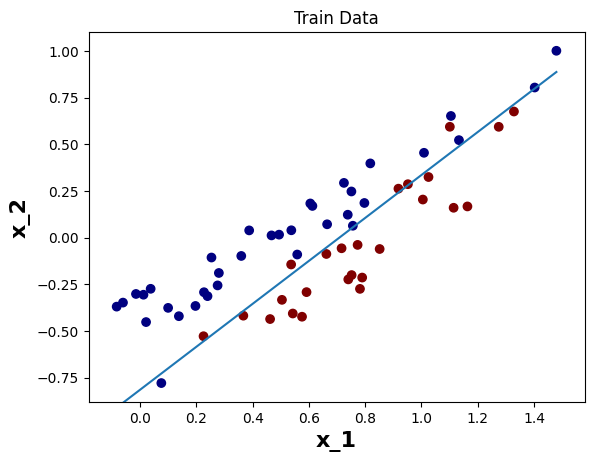

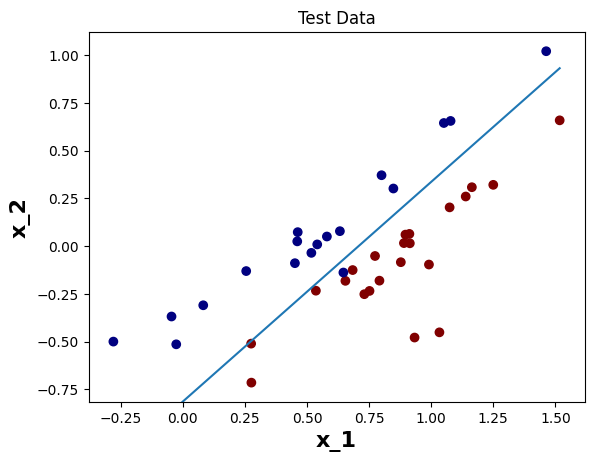

In [10]:
from visualization.classifications import model_plot

# Train Data
model_plot(model,X_train,y_train,'Train Data')
# Test Dataset Result9s
model_plot(model,X_test,y_test,'Test Data')

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

def plot_point_cloud_interactive(pc):
    def plot(elev=30, azim=30):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        xs = pc[:, 0]
        ys = pc[:, 1]
        zs = pc[:, 2]

        ax.scatter(xs, ys, zs, marker='o')

        ax.set_xlabel('X Label')
        ax.set_ylabel('Y Label')
        ax.set_zlabel('Z Label')

        ax.view_init(elev, azim)
        plt.show()

    widgets.interact(plot, elev=(-90, 90, 5), azim=(-180, 180, 5))

PC_scenes = read_nuscenes_data()
PC_scene = PC_scenes[0]
PC_pair = PC_scene[0]

#plot_point_cloud_interactive(PC_pair.PC0.pc.cpu().numpy())


import plotly.graph_objs as go

def plot_point_cloud_plotly(pc):
    x, y, z = pc[:, 0], pc[:, 1], pc[:, 2]

    trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            opacity=0.8
        )
    )

    layout = go.Layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )

    fig = go.Figure(data=[trace], layout=layout)
    fig.show()

plot_point_cloud_plotly(PC_pair.PC0.pc.cpu().numpy())
